In [42]:
print('Radha!')

Radha!


In [43]:
from typing import TypedDict
from dotenv import  load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

In [44]:
class JobPilotState(TypedDict):
    query: str
    jobs: list
    selected_job: dict
    match_score: int
    application: dict
    human_decision: str
    result: str

In [45]:
def search_jobs(state: JobPilotState):

    jobs = [
        {
            "id": 1,
            "title": "Generative AI Intern",
            "company": "AI Labs",
            "location": "Remote",
            "skills": ["Python", "LangChain", "LLM", "LangGraph"]
        },
        {
            "id": 2,
            "title": "Backend Developer Intern",
            "company": "TechCorp",
            "location": "Bangalore",
            "skills": ["Python", "FastAPI", "PostgreSQL"]
        },
        {
            "id": 3,
            "title": "Data Analyst Intern",
            "company": "DataWorks",
            "location": "Remote",
            "skills": ["Python", "SQL", "Pandas"]
        }
    ]

    return {
        "jobs": jobs
    }

In [46]:
def select_job(state: JobPilotState):


    # For learning, we'll keep selection simple.
    selected = state["jobs"][0]

    return {
        "selected_job": selected,
        "match_score": 92
    }

In [47]:
def prepare_application(state: JobPilotState):

    job = state["selected_job"]

    application = {
        "job": job["title"],
        "company": job["company"],
        "location": job["location"],
        "match_score": state["match_score"],
        "resume": "Deepak_Kumar_Singh_Resume.pdf",
        "cover_letter": (
            f"Dear Hiring Team,\n\n"
            f"I am interested in the {job['title']} position "
            f"at {job['company']}."
        )
    }

    return {
        "application": application
    }

In [48]:
def human_review(state: JobPilotState):

    review = interrupt({
        "type": "job_application_review",
        "message": "Review this application before submission.",
        "application": state["application"],
        "options": [
            "approve",
            "reject",
            "edit"
        ]
    })

    return {
        "human_decision": review
    }

In [49]:
def process_decision(state: JobPilotState):

    decision = state["human_decision"]

    if decision == "approve":
        return {
            "result": "Application approved."
        }

    if decision == "reject":
        return {
            "result": "Application rejected by user."
        }

    return {
        "result": "Application requires editing."
    }

In [50]:
def submit_application(state: JobPilotState):

    if state["human_decision"] != "approve":
        return {
            "result": "Application was not submitted."
        }

    job = state["selected_job"]

    return {
        "result": (
            f"Application submitted to "
            f"{job['company']} for {job['title']}."
        )
    }

In [51]:
builder = StateGraph(JobPilotState)

builder.add_node("search_jobs", search_jobs)
builder.add_node("select_job", select_job)
builder.add_node("prepare_application", prepare_application)
builder.add_node("human_review", human_review)
builder.add_node("process_decision", process_decision)
builder.add_node("submit_application", submit_application)

builder.add_edge(START, "search_jobs")
builder.add_edge("search_jobs", "select_job")
builder.add_edge("select_job", "prepare_application")
builder.add_edge("prepare_application", "human_review")
builder.add_edge("human_review", "process_decision")
builder.add_edge("process_decision", "submit_application")
builder.add_edge("submit_application", END)

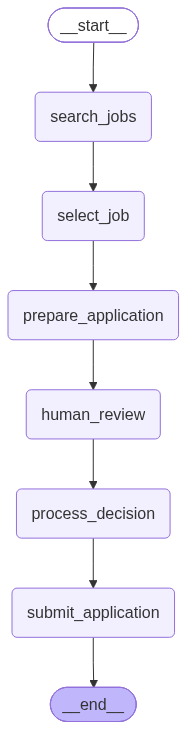

In [52]:
checkpointer = InMemorySaver()

graph = builder.compile(
    checkpointer=checkpointer
)
graph

In [58]:
config = {
    "configurable": {
        "thread_id": "jobpilot-v2-001"
    }
}

result = graph.invoke(
    {
        "query": "Find the best Generative AI internship for me.",
        "jobs": [],
        "selected_job": {},
        "match_score": 0,
        "application": {},
        "human_decision": "",
        "result": ""
    },
    config=config
)
result

{'query': 'Find the best Generative AI internship for me.',
 'jobs': [{'id': 1,
   'title': 'Generative AI Intern',
   'company': 'AI Labs',
   'location': 'Remote',
   'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
  {'id': 2,
   'title': 'Backend Developer Intern',
   'company': 'TechCorp',
   'location': 'Bangalore',
   'skills': ['Python', 'FastAPI', 'PostgreSQL']},
  {'id': 3,
   'title': 'Data Analyst Intern',
   'company': 'DataWorks',
   'location': 'Remote',
   'skills': ['Python', 'SQL', 'Pandas']}],
 'selected_job': {'id': 1,
  'title': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
 'match_score': 92,
 'application': {'job': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'match_score': 92,
  'resume': 'Deepak_Kumar_Singh_Resume.pdf',
  'cover_letter': 'Dear Hiring Team,\n\nI am interested in the Generative AI Intern position at AI Labs.'},
 'human_decision'

In [55]:
result = graph.invoke(
    Command(resume="approve"),
    config=config
)
result

{'query': 'Find the best Generative AI internship for me.',
 'jobs': [{'id': 1,
   'title': 'Generative AI Intern',
   'company': 'AI Labs',
   'location': 'Remote',
   'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
  {'id': 2,
   'title': 'Backend Developer Intern',
   'company': 'TechCorp',
   'location': 'Bangalore',
   'skills': ['Python', 'FastAPI', 'PostgreSQL']},
  {'id': 3,
   'title': 'Data Analyst Intern',
   'company': 'DataWorks',
   'location': 'Remote',
   'skills': ['Python', 'SQL', 'Pandas']}],
 'selected_job': {'id': 1,
  'title': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
 'match_score': 92,
 'application': {'job': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'match_score': 92,
  'resume': 'Deepak_Kumar_Singh_Resume.pdf',
  'cover_letter': 'Dear Hiring Team,\n\nI am interested in the Generative AI Intern position at AI Labs.'},
 'human_decision'

In [57]:
result = graph.invoke(
    Command(resume="reject"),
    config=config
)
result

{'query': 'Find the best Generative AI internship for me.',
 'jobs': [{'id': 1,
   'title': 'Generative AI Intern',
   'company': 'AI Labs',
   'location': 'Remote',
   'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
  {'id': 2,
   'title': 'Backend Developer Intern',
   'company': 'TechCorp',
   'location': 'Bangalore',
   'skills': ['Python', 'FastAPI', 'PostgreSQL']},
  {'id': 3,
   'title': 'Data Analyst Intern',
   'company': 'DataWorks',
   'location': 'Remote',
   'skills': ['Python', 'SQL', 'Pandas']}],
 'selected_job': {'id': 1,
  'title': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
 'match_score': 92,
 'application': {'job': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'match_score': 92,
  'resume': 'Deepak_Kumar_Singh_Resume.pdf',
  'cover_letter': 'Dear Hiring Team,\n\nI am interested in the Generative AI Intern position at AI Labs.'},
 'human_decision'

In [59]:
result = graph.invoke(
    Command(resume="edit"),
    config=config
)
result

{'query': 'Find the best Generative AI internship for me.',
 'jobs': [{'id': 1,
   'title': 'Generative AI Intern',
   'company': 'AI Labs',
   'location': 'Remote',
   'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
  {'id': 2,
   'title': 'Backend Developer Intern',
   'company': 'TechCorp',
   'location': 'Bangalore',
   'skills': ['Python', 'FastAPI', 'PostgreSQL']},
  {'id': 3,
   'title': 'Data Analyst Intern',
   'company': 'DataWorks',
   'location': 'Remote',
   'skills': ['Python', 'SQL', 'Pandas']}],
 'selected_job': {'id': 1,
  'title': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'skills': ['Python', 'LangChain', 'LLM', 'LangGraph']},
 'match_score': 92,
 'application': {'job': 'Generative AI Intern',
  'company': 'AI Labs',
  'location': 'Remote',
  'match_score': 92,
  'resume': 'Deepak_Kumar_Singh_Resume.pdf',
  'cover_letter': 'Dear Hiring Team,\n\nI am interested in the Generative AI Intern position at AI Labs.'},
 'human_decision'